In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'financial_regression.csv', encoding="latin1")
print(df)

            date  sp500 open  sp500 high  sp500 low  sp500 close  \
0     2010-01-14      114.49    115.1400   114.4200       114.93   
1     2010-01-15      114.73    114.8400   113.2000       113.64   
2     2010-01-18         NaN         NaN        NaN          NaN   
3     2010-01-19      113.62    115.1300   113.5900       115.06   
4     2010-01-20      114.28    114.4500   112.9800       113.89   
...          ...         ...         ...        ...          ...   
3899  2024-10-17      585.91    586.1200   582.1600       582.35   
3900  2024-10-18      584.07    585.3900   582.5800       584.59   
3901  2024-10-21      583.85    584.8500   580.6001       583.63   
3902  2024-10-22      581.05    584.5000   580.3800       583.32   
3903  2024-10-23      581.26    581.7086   574.4150       577.99   

      sp500 volume  sp500 high-low  nasdaq open  nasdaq high  nasdaq low  ...  \
0      115646960.0          0.7200        46.26       46.520     46.2200  ...   
1      212252769.0   

In [2]:
df.head()

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


In [3]:
df.tail()

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
3899,2024-10-17,585.91,586.1200,582.1600,582.35,34393714.0,3.9600,496.44,496.490,491.1901,...,96.0259,94.5400,95.68,52414.0,1.4859,247.75,249.06,247.62,248.63,5176170.0
3900,2024-10-18,584.07,585.3900,582.5800,584.59,37416801.0,2.8100,494.06,495.570,493.3000,...,99.6600,97.2700,99.46,205027.0,2.3900,250.00,251.37,249.90,251.27,7833614.0
3901,2024-10-21,583.85,584.8500,580.6001,583.63,36439010.0,4.2499,493.25,496.230,491.3100,...,98.3500,95.8900,97.35,227394.0,2.4600,252.74,253.14,250.73,251.22,9258590.0
3902,2024-10-22,581.05,584.5000,580.3800,583.32,34183835.0,4.1200,492.73,497.445,491.9700,...,99.5899,97.9600,99.41,136431.0,1.6299,253.06,253.94,252.52,253.93,5756321.0
3903,2024-10-23,581.26,581.7086,574.4150,577.99,47444991.0,7.2936,493.59,494.250,485.0500,...,98.5500,96.4643,97.53,81133.0,2.0857,253.08,253.18,250.20,250.87,7899995.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3904 non-null   object 
 1   sp500 open          3719 non-null   float64
 2   sp500 high          3719 non-null   float64
 3   sp500 low           3719 non-null   float64
 4   sp500 close         3719 non-null   float64
 5   sp500 volume        3719 non-null   float64
 6   sp500 high-low      3719 non-null   float64
 7   nasdaq open         3719 non-null   float64
 8   nasdaq high         3719 non-null   float64
 9   nasdaq low          3719 non-null   float64
 10  nasdaq close        3719 non-null   float64
 11  nasdaq volume       3719 non-null   float64
 12  nasdaq high-low     3719 non-null   float64
 13  us_rates_%          176 non-null    float64
 14  CPI                 176 non-null    float64
 15  usd_chf             3694 non-null   float64
 16  eur_us

In [5]:
df.columns

Index(['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close',
       'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high',
       'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low',
       'us_rates_%', 'CPI', 'usd_chf', 'eur_usd', 'GDP', 'silver open',
       'silver high', 'silver low', 'silver close', 'silver volume',
       'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close',
       'oil volume', 'oil high-low', 'platinum open', 'platinum high',
       'platinum low', 'platinum close', 'platinum volume',
       'platinum high-low', 'palladium open', 'palladium high',
       'palladium low', 'palladium close', 'palladium volume',
       'palladium high-low', 'gold open', 'gold high', 'gold low',
       'gold close', 'gold volume'],
      dtype='object')

In [6]:
df.isnull().sum()

date                     0
sp500 open             185
sp500 high             185
sp500 low              185
sp500 close            185
sp500 volume           185
sp500 high-low         185
nasdaq open            185
nasdaq high            185
nasdaq low             185
nasdaq close           185
nasdaq volume          185
nasdaq high-low        185
us_rates_%            3728
CPI                   3728
usd_chf                210
eur_usd                210
GDP                   3847
silver open            185
silver high            185
silver low             185
silver close           185
silver volume          185
silver high-low        185
oil open               185
oil high               185
oil low                185
oil close              185
oil volume             185
oil high-low           185
platinum open          185
platinum high          185
platinum low           185
platinum close         185
platinum volume        185
platinum high-low      185
palladium open         185
p

In [7]:
df.describe(include="all")

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
count,3904,3719.000000,3719.000000,3719.000000,3719.000000,3.719000e+03,3719.000000,3719.000000,3719.000000,3719.00000,...,3719.000000,3719.000000,3719.000000,3.719000e+03,3719.000000,3719.000000,3719.000000,3719.000000,3719.000000,3.719000e+03
unique,3904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2010-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,268.732724,270.179765,267.157446,268.779352,1.124206e+08,3.022320,181.394495,182.689784,179.98249,...,110.184473,107.931862,109.067990,7.169556e+04,2.252611,145.454975,146.101477,144.761329,145.453861,9.658138e+06
std,NaN,121.374890,122.024860,120.663204,121.393684,6.902901e+07,2.656917,122.468973,123.393400,121.43517,...,58.454170,56.877967,57.688191,9.790703e+04,2.543622,29.604259,29.754711,29.422517,29.611348,6.182342e+06
min,NaN,103.110000,103.420000,101.130000,102.200000,1.708170e+05,0.300000,42.670000,42.821500,41.55000,...,40.550000,38.490000,40.090000,3.157000e+03,0.230000,100.920000,100.990000,100.232600,100.500000,1.436508e+06
25%,NaN,169.715000,170.175000,169.030000,169.650000,6.699112e+07,1.280000,78.700000,79.150000,78.31500,...,69.400000,68.270000,68.820000,2.085900e+04,0.870000,120.555000,121.030000,120.170000,120.590000,5.795310e+06
50%,NaN,241.180000,242.080000,239.450000,240.610000,9.239907e+07,2.090000,138.720000,139.420000,138.02000,...,83.900000,82.650000,83.210000,3.829500e+04,1.414000,137.620000,138.140000,136.990000,137.710000,8.087993e+06
75%,NaN,374.455000,377.800000,371.045000,374.255000,1.367146e+08,3.815000,284.165000,287.590000,281.23000,...,143.785000,140.480000,142.040000,8.420700e+04,2.680000,167.770000,168.412500,167.055000,167.835000,1.156729e+07


In [8]:
df.corr(numeric_only=True)

,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,nasdaq close,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
sp500 open,1.000000,0.999916,0.999889,0.999810,-0.514871,0.513681,0.991532,0.991454,0.991491,0.991358,...,0.644674,0.644103,0.644019,-0.295577,0.412253,0.681216,0.679174,0.684501,0.681244,-0.283442
sp500 high,0.999916,1.000000,0.999823,0.999880,-0.511390,0.520522,0.991573,0.991627,0.991556,0.991538,...,0.646575,0.645874,0.645887,-0.295013,0.416337,0.681915,0.679919,0.685170,0.681964,-0.281198
sp500 low,0.999889,0.999823,1.000000,0.999898,-0.520291,0.504377,0.991320,0.991262,0.991461,0.991325,...,0.642729,0.642293,0.642185,-0.296271,0.408034,0.680457,0.678383,0.683810,0.680525,-0.286875
sp500 close,0.999810,0.999880,0.999898,1.000000,-0.516595,0.511622,0.991378,0.991433,0.991516,0.991548,...,0.644616,0.644060,0.644041,-0.295603,0.411877,0.681226,0.679190,0.684539,0.681309,-0.284437
sp500 volume,-0.514871,-0.511390,-0.520291,-0.516595,1.000000,0.142159,-0.467185,-0.464952,-0.470823,-0.468469,...,-0.320783,-0.329425,-0.325452,0.461173,-0.005533,-0.166782,-0.162057,-0.173572,-0.167480,0.582209
sp500 high-low,0.513681,0.520522,0.504377,0.511622,0.142159,1.000000,0.519660,0.524764,0.512485,0.517817,...,0.506002,0.493619,0.499144,-0.094053,0.590448,0.415688,0.418188,0.412921,0.414887,0.113734
nasdaq open,0.991532,0.991573,0.991320,0.991378,-0.467185,0.519660,1.000000,0.999929,0.999901,0.999811,...,0.645686,0.644569,0.644717,-0.249597,0.425092,0.738224,0.736407,0.741082,0.738189,-0.241723
nasdaq high,0.991454,0.991627,0.991262,0.991433,-0.464952,0.524764,0.999929,1.000000,0.999871,0.999896,...,0.647291,0.646068,0.646293,-0.249156,0.428455,0.738588,0.736806,0.741425,0.738573,-0.240090
nasdaq low,0.991491,0.991556,0.991461,0.991516,-0.470823,0.512485,0.999901,0.999871,1.000000,0.999915,...,0.644100,0.643081,0.643214,-0.249942,0.421907,0.737751,0.735915,0.740660,0.737749,-0.244035
nasdaq close,0.991358,0.991538,0.991325,0.991548,-0.468469,0.517817,0.999811,0.999896,0.999915,1.000000,...,0.645802,0.644698,0.644899,-0.249521,0.424877,0.738136,0.736326,0.741017,0.738153,-0.242344


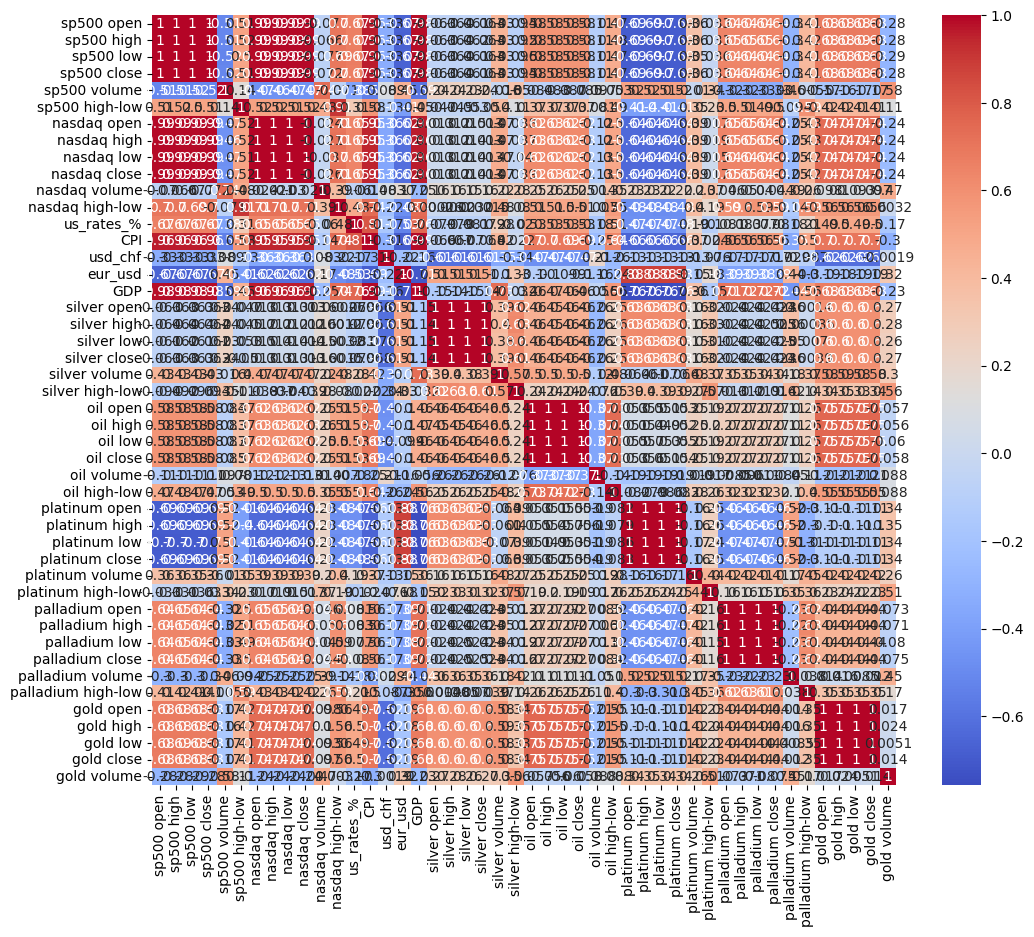

In [9]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import  KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [11]:
df.dropna(how="all", inplace=True)

In [12]:
df["gold_direction"] = (df["gold close"] > df["gold open"]).astype(int)

In [13]:
df["gold_direction"].value_counts()

gold_direction
0    2061
1    1843
Name: count, dtype: int64

In [14]:
feature_cols = df.select_dtypes(include=['float64', 'int64']).columns
feature_cols = [col for col in feature_cols if col not in ['gold_direction', 'gold close']]
X = df[feature_cols].dropna()

In [15]:
y_reg = df.loc[X.index, 'gold close'].dropna()

In [16]:
y_clf = df.loc[X.index, 'gold_direction'].dropna()

In [17]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_clf_train)
logreg_pred = logreg.predict(X_test_scaled)
logreg_proba = logreg.predict_proba(X_test_scaled)

logreg_acc = accuracy_score(y_clf_test, logreg_pred)

In [20]:
print(f"Accuracy: {logreg_acc:.3f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, logreg_pred, target_names=['Down', 'Up']))

Accuracy: 0.167

Classification Report:
              precision    recall  f1-score   support

        Down       0.33      0.25      0.29         4
          Up       0.00      0.00      0.00         2

    accuracy                           0.17         6
   macro avg       0.17      0.12      0.14         6
weighted avg       0.22      0.17      0.19         6



In [21]:
knn_reg = KNeighborsRegressor(n_neighbors=6)
knn_reg.fit(X_train_scaled, y_reg_train)
knn_reg_pred = knn_reg.predict(X_test_scaled)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


knn_rmse = np.sqrt(mean_squared_error(y_reg_test, knn_reg_pred))
knn_r2 = r2_score(y_reg_test, knn_reg_pred)

print("RMSE:", knn_rmse)
print("R²:", knn_r2)


RMSE: 10.97551972953141
R²: 0.8510613911961615


In [23]:
knn_rmse = np.sqrt(mean_squared_error(y_reg_test, knn_reg_pred))
knn_r2 = r2_score(y_reg_test, knn_reg_pred)

In [24]:
print(f"RMSE: {knn_rmse:.2f}")
print(f"R² Score: {knn_r2:.3f}")
print(f"Predictions range: {knn_reg_pred.min():.2f} - {knn_reg_pred.max():.2f}")
print(f"Actual range: {y_reg_test.min():.2f} - {y_reg_test.max():.2f}")

RMSE: 10.98
R² Score: 0.851
Predictions range: 118.35 - 172.59
Actual range: 112.57 - 179.50


In [25]:

probs_up = logreg_proba[:, 1]
top_indices = np.argsort(probs_up)[-5:]
for idx in top_indices:
    print(f"Sample {idx}: {probs_up[idx]:.3f} (actual: {y_clf_test.iloc[idx]})")

Sample 1: 0.345 (actual: 1)
Sample 3: 0.471 (actual: 1)
Sample 5: 0.582 (actual: 0)
Sample 0: 0.594 (actual: 0)
Sample 4: 0.745 (actual: 0)


In [26]:

df['date'] = pd.to_datetime(df['date'])  
df = df.drop(columns=['date'])

In [27]:
X = df.drop(columns=['sp500 close'])
y = df['sp500 close']

In [28]:
X = X.select_dtypes(include=['int64', 'float64'])

In [29]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
coeff_df = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)

coeff_df

,Coefficient
sp500 open,-17.005412
sp500 high,67.332525
sp500 low,68.106478
sp500 volume,-0.100885
sp500 high-low,0.111259
nasdaq open,21.751957
nasdaq high,-67.306458
nasdaq low,-68.410055
nasdaq close,113.956463
nasdaq volume,0.056774
